In [1]:
!curl -L -o ecoli_1k.fna https://ctlab.itmo.ru/~aivanov/ct_algo_2026/ecoli_1k.fna

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80991  100 80991    0     0   178k      0 --:--:-- --:--:-- --:--:--  178k


In [2]:
!curl -L -o ecoli_reads.fastq https://ctlab.itmo.ru/~aivanov/ct_algo_2026/ecoli_reads.fastq

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2710k  100 2710k    0     0  2086k      0  0:00:01  0:00:01 --:--:-- 2086k


In [3]:
!head -n 10 ecoli_1k.fna

>NC_000913.3 Escherichia coli str. K-12 substr. MG1655, complete genome
AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTCTGATAGCAGCTTCTGAACTG
GTTACCTGCCGTGAGTAAATTAAAATTTTATTGACTTAGGTCACTAAATACTTTAACCAATATAGGCATAGCGCACAGAC
AGATAAAAATTACAGAGTACACAACATCCATGAAACGCATTAGCACCACCATTACCACCACCATCACCATTACCACAGGT
AACGGTGCGGGCTGACGCGTACAGGAAACACAGAAAAAAGCCCGCACCTGACAGTGCGGGCTTTTTTTTTCGACCAAAGG
TAACGAGGTAACAACCATGCGAGTGTTGAAGTTCGGCGGTACATCAGTGGCAAATGCAGAACGTTTTCTGCGTGTTGCCG
ATATTCTGGAAAGCAATGCCAGGCAGGGGCAGGTGGCCACCGTCCTCTCTGCCCCCGCCAAAATCACCAACCACCTGGTG
GCGATGATTGAAAAAACCATTAGCGGCCAGGATGCTTTACCCAATATCAGCGATGCCGAACGTATTTTTGCCGAACTTTT
GACGGGACTCGCCGCCGCCCAGCCGGGGTTCCCGCTGGCGCAATTGAAAACTTTCGTCGATCAGGAATTTGCCCAAATAA
AACATGTCCTGCATGGCATTAGTTTGTTGGGGCAGTGCCCGGATAGCATCAACGCTGCGCTGATTTGCCGTGGCGAGAAA


In [4]:
!head -n 8 ecoli_reads.fastq

@NC_000913.3_0_0/1
CTCCTTTATGACCCAGACCACGCTGTCGGTGGATGACACGTCTGATGTGATCGACGCGCTGCGTAAACGCTTCCCGAAAATTGTCGGTCCGCGCAAAGATGACATCTGCGACGCCACGACTAACCG
+
B//BBFFFFF<<///FFFFFF/FF/B/<B/BF<B/FF7BFF<F<FF/FFF7BF/<B//<F<F/FBFFF</FBFF//<</F/BFFFBF<B/<F///7/B/FF</F</</F//B//F7F7/7///B7<
@NC_000913.3_1_0/1
GCCTGGCCACGGCCCGGACGACTATGTGATCGGTCAGAAATACGGCCTGGAAACCGCTAACCCGGTTGGCCCGGACGGCACTTATCTGCCGGGCACTTATCCGACGCTGGATGGCGTGAACGTCTT
+
BBBBBFFFFFFFFFF/FF<FFFFFFFFFFFFFFFFFFFFFFF<FFFFFFFFFFFFFFFFBFFFFBFF<FBFFFFFFFFFFFBFFFFFFFFFFFBFFFFFFFFF/7FFFFFF<FFFBFFFFFFFFF/


In [5]:
!pip install biopython

In [6]:
!pip install --upgrade pip

In [7]:
from Bio import SeqIO
from typing import Iterable


def parse_fastq(path: str) -> Iterable[SeqIO.SeqRecord]:
    with open(path, 'r') as f:
        for record in SeqIO.parse(f, 'fastq'):
            yield record

In [8]:
data = tuple(parse_fastq('ecoli_reads.fastq'))
print(data[:2], len(data), sep='\n')

(SeqRecord(seq=Seq('CTCCTTTATGACCCAGACCACGCTGTCGGTGGATGACACGTCTGATGTGATCGA...CCG'), id='NC_000913.3_0_0/1', name='NC_000913.3_0_0/1', description='NC_000913.3_0_0/1', dbxrefs=[]), SeqRecord(seq=Seq('GCCTGGCCACGGCCCGGACGACTATGTGATCGGTCAGAAATACGGCCTGGAAAC...CTT'), id='NC_000913.3_1_0/1', name='NC_000913.3_1_0/1', description='NC_000913.3_1_0/1', dbxrefs=[]))
10000


In [9]:
print(max(len(r.seq) for r in data), min(len(r.seq) for r in data))

126 126


In [10]:
from Bio.Seq import Seq
from dataclasses import dataclass
from collections import defaultdict
from typing import NewType

KMer = NewType('KMer', str)


@dataclass
class Edge:
    depth: int = 0


class DeBruijnGraph:
    def __init__(self, k: int):
        self.k = k
        self.nodes: set[KMer] = set()
        self.edges: defaultdict[tuple[KMer, KMer], Edge] = defaultdict(Edge)

    def build(self, reads: Iterable[Seq]):
        for read in reads:
            self.add(str(read))

    def add(self, seq: str):
        assert len(seq) >= self.k, "Read is too short to be added to the graph"

        for i in range(len(seq) - self.k):
            k_mer_from, k_mer_to = KMer(seq[i:i + self.k]), KMer(seq[i + 1:i + self.k + 1])
            self.nodes.add(k_mer_from)
            self.nodes.add(k_mer_to)
            self.edges[(k_mer_from, k_mer_to)].depth += 1

In [11]:
@dataclass(frozen=True)
class CompactedEdge:
    depth_sum: int
    target: KMer
    seq: str
    kmers_number: int


class CompressedDeBruijnGraph:
    def __init__(self, k: int):
        self.k = k

        self.nodes: set[KMer] = set()
        self.in_edges: defaultdict[KMer, set[KMer]] = defaultdict(set)
        self.out_edges: defaultdict[KMer, set[KMer]] = defaultdict(set)

        self.edges: defaultdict[tuple[KMer, KMer], Edge] = defaultdict(Edge)
        self.compacted_edges: defaultdict[KMer, list[CompactedEdge]] = defaultdict(list)

    def build(self, reads: Iterable[Seq]):
        for read in reads:
            self.add(str(read))

        self.compact()

    def compact(self):
        visited = set()

        for node in self.nodes:
            # start node for a unitig: not visited and not an internal node of a linear path
            if node in visited or (self.indegree(node) == 1 and self.outdegree(node) == 1):
                continue

            for next_node in self.out_edges[node]:
                path = [node, next_node]
                depth_sum = self.edges[(node, next_node)].depth

                current = next_node
                while self.indegree(current) == 1 and self.outdegree(current) == 1:
                    nxt = next(iter(self.out_edges[current]))
                    path.append(nxt)
                    depth_sum += self.edges[(current, nxt)].depth
                    current = nxt

                visited.update(path)
                self.compacted_edges[node].append(CompactedEdge(
                    depth_sum=depth_sum,
                    target=current,
                    seq=node + ''.join(n[-1] for n in path[1:]),
                    kmers_number=len(path) - 1
                ))

    def add(self, seq: str):
        assert len(seq) >= self.k, "Read is too short to be added to the graph"

        for i in range(len(seq) - self.k):
            k_mer_from, k_mer_to = KMer(seq[i:i + self.k]), KMer(seq[i + 1:i + self.k + 1])

            self.nodes.add(k_mer_from)
            self.nodes.add(k_mer_to)
            self.out_edges[k_mer_from].add(k_mer_to)
            self.in_edges[k_mer_to].add(k_mer_from)

            self.edges[(k_mer_from, k_mer_to)].depth += 1

    def indegree(self, node: KMer) -> int:
        return len(self.in_edges[node])

    def outdegree(self, node: KMer) -> int:
        return len(self.out_edges[node])

In [12]:
def export_to_gfa(g: CompressedDeBruijnGraph, path: str):
    """
    Exports DeBruijn graph to GFA format (unitigs + links).
    Each unitig gets a unique ID.
    Links preserve all branches with correct overlap.
    """

    with open(path, 'w') as f:
        f.write('H\tVN:Z:1.0\n')

        edge_ids: dict[tuple[KMer, KMer, str], str] = {}
        eid = 0
        for start, edges in g.compacted_edges.items():
            for edge in edges:
                edge_ids[(start, edge.target, edge.seq)] = f"e{eid}"
                f.write(f"S\te{eid}\t{edge.seq}\n")
                eid += 1

        for start, edges in g.compacted_edges.items():
            for edge in edges:
                src_id = edge_ids[(start, edge.target, edge.seq)]
                for next_edge in g.compacted_edges.get(edge.target, []):
                    dst_id = edge_ids.get((edge.target, next_edge.target, next_edge.seq))
                    if dst_id is not None:
                        f.write(f"L\t{src_id}\t+\t{dst_id}\t+\t{g.k - 1}M\n")

In [13]:
!pip install pillow

In [14]:
from abc import ABC, abstractmethod


class GraphHeuristic(ABC):
    """
    Abstract base class for graph heuristics.
    Each heuristic takes a CompressedDeBruijnGraph as input and returns a new graph
    after applying its filtering logic.
    This allows building pipelines of heuristics without mutating the original graph.
    """

    @abstractmethod
    def apply(self, g: CompressedDeBruijnGraph) -> CompressedDeBruijnGraph:
        pass


class LowCoverageRemoval(GraphHeuristic):
    """
    Removes low-coverage unitigs from the graph.

    The coverage of a unitig is computed as:
        average_coverage = depth_sum / kmers_number

    Only unitigs with average coverage >= min_coverage are retained.
    """

    def __init__(self, min_coverage: int):
        self.min_coverage = min_coverage

    def apply(self, g: CompressedDeBruijnGraph) -> CompressedDeBruijnGraph:
        new_g = CompressedDeBruijnGraph(k=g.k)

        for start, edges in g.compacted_edges.items():
            for edge in edges:
                avg_coverage = edge.depth_sum / edge.kmers_number
                if avg_coverage >= self.min_coverage:
                    new_g.add(edge.seq)

        return new_g


class TipRemoval(GraphHeuristic):
    """
    Removes short tips (dead-end unitigs) from the graph.

    A tip is defined as a unitig whose start node has no incoming edges
    or whose end node (edge.target) has no outgoing edges.

    Only tips shorter than min_length (in k+1-mers) are removed.
    """

    def __init__(self, min_length: int):
        self.min_length = min_length

    def apply(self, g: CompressedDeBruijnGraph) -> CompressedDeBruijnGraph:
        new_g = CompressedDeBruijnGraph(k=g.k)

        for start, edges in g.compacted_edges.items():
            for edge in edges:
                is_tip = g.indegree(edge.target) == 0 or g.outdegree(edge.target) == 0
                if not is_tip or edge.kmers_number >= self.min_length:
                    new_g.add(edge.seq)

        return new_g


class GraphPipeline(GraphHeuristic):
    """
    Composes multiple heuristics into a single pipeline.
    Heuristics are applied sequentially, and the output of one is the input to the next.
    """

    def __init__(self, heuristics: list[GraphHeuristic]):
        self.heuristics = heuristics

    def apply(self, g: CompressedDeBruijnGraph) -> CompressedDeBruijnGraph:
        for heuristic in self.heuristics:
            g = heuristic.apply(g)
            g.compact()

        return g

In [15]:
def pipeline_analysis(reads: tuple[Seq, ...]):
    k_values = (5, 7, 11, 21, 31, 41, 51, 61, 71)

    for i in k_values:
        g = CompressedDeBruijnGraph(k=i)
        g.build(reads)

        cleaner = GraphPipeline([
            LowCoverageRemoval(min_coverage=2),
            TipRemoval(min_length=3)
        ])

        clean_graph = cleaner.apply(g)
        export_to_gfa(clean_graph, f"graphs/graph_k{i}.gfa")

In [16]:
pipeline_analysis(tuple(r.seq for r in data))

In [17]:
from PIL import Image
from IPython.display import display


def show_images(paths: Iterable[str]):
    for path in paths:
        img = Image.open(path)
        display(img)

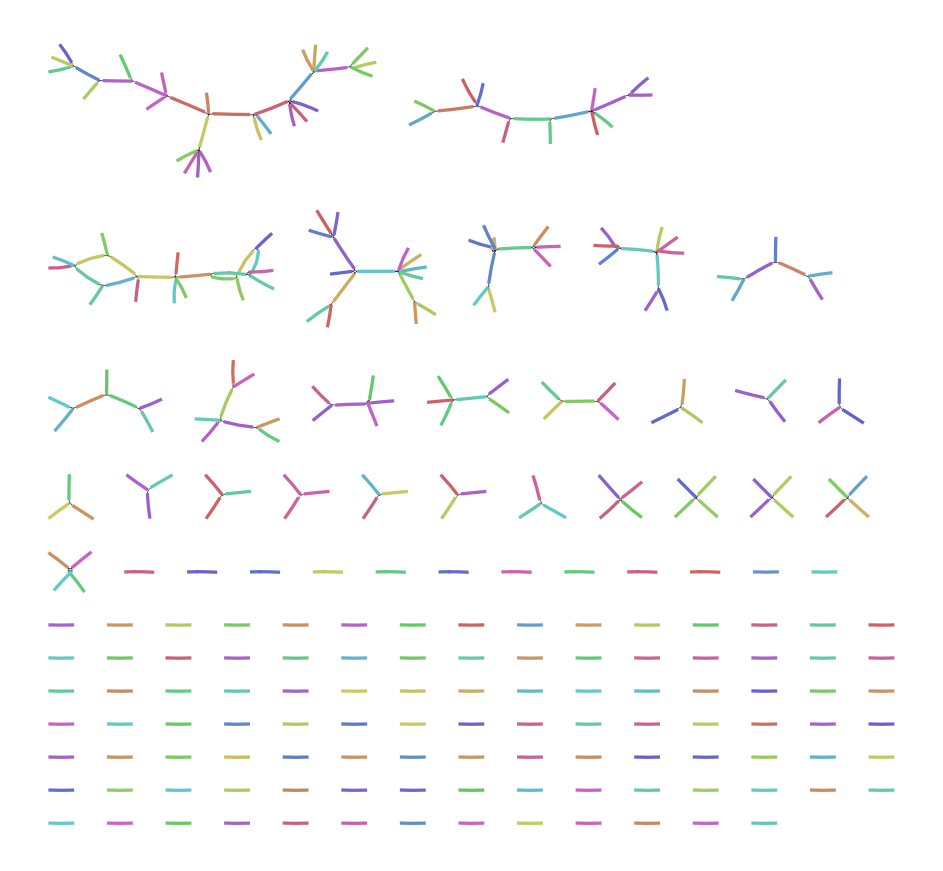

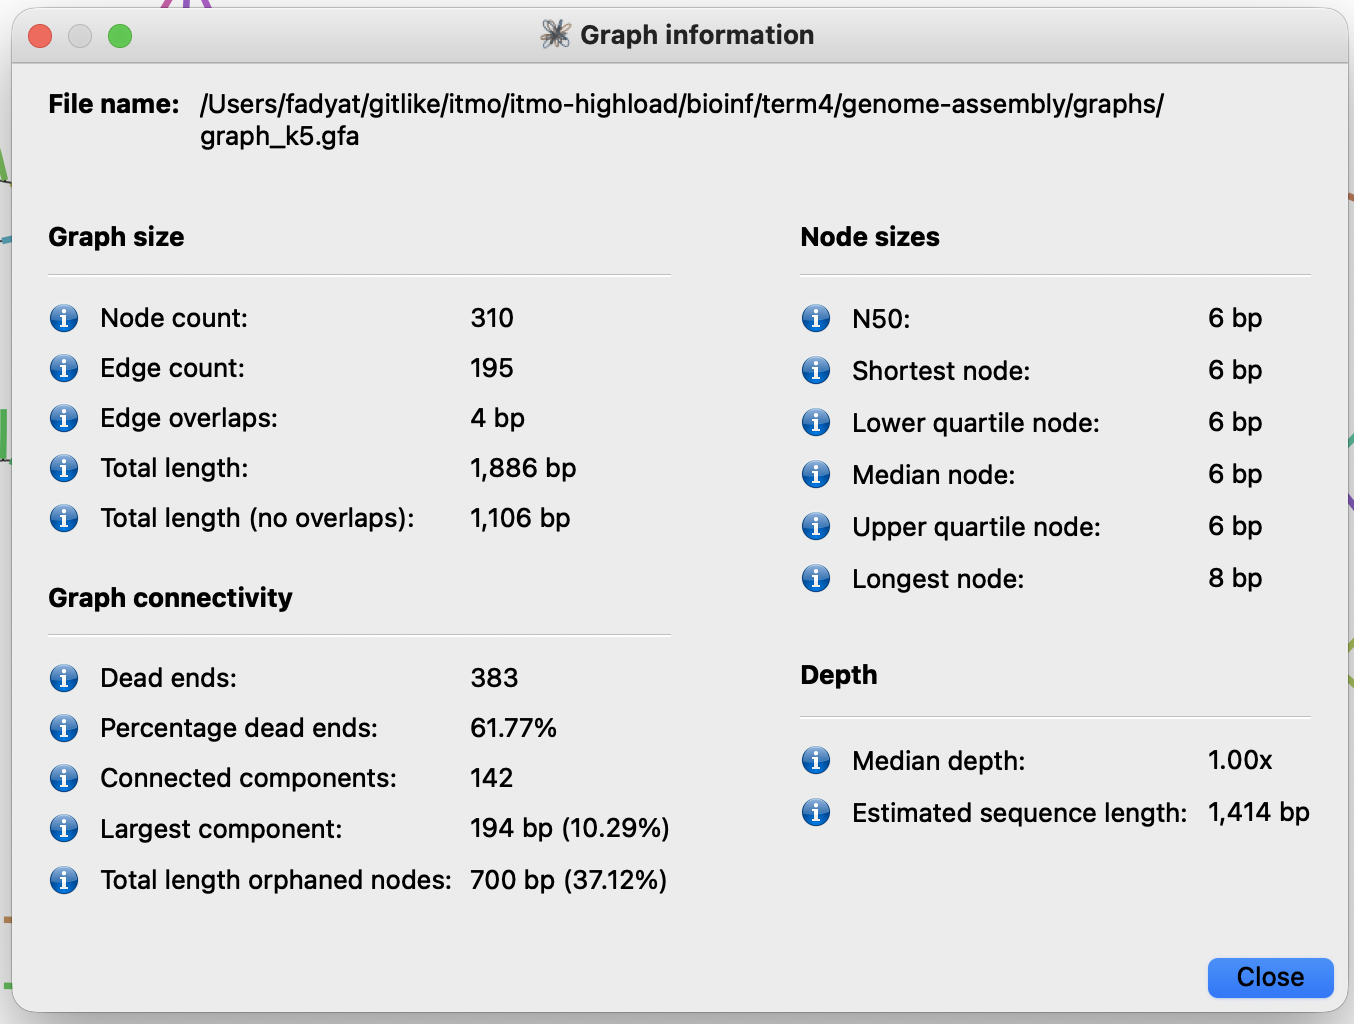

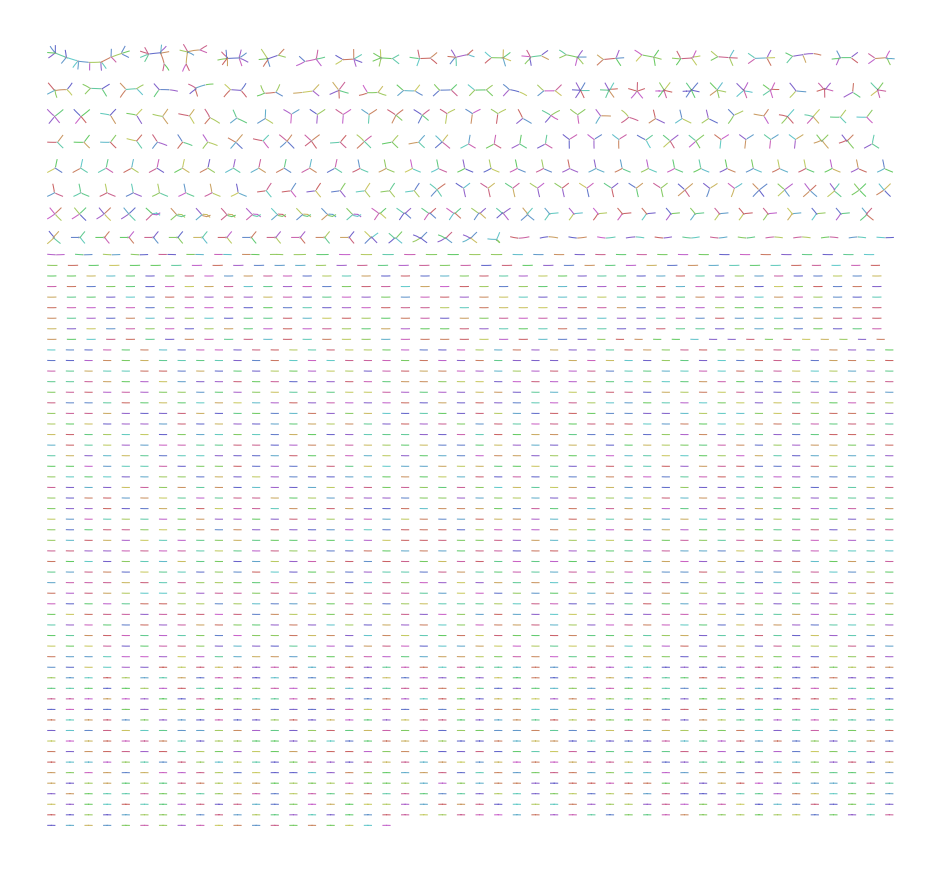

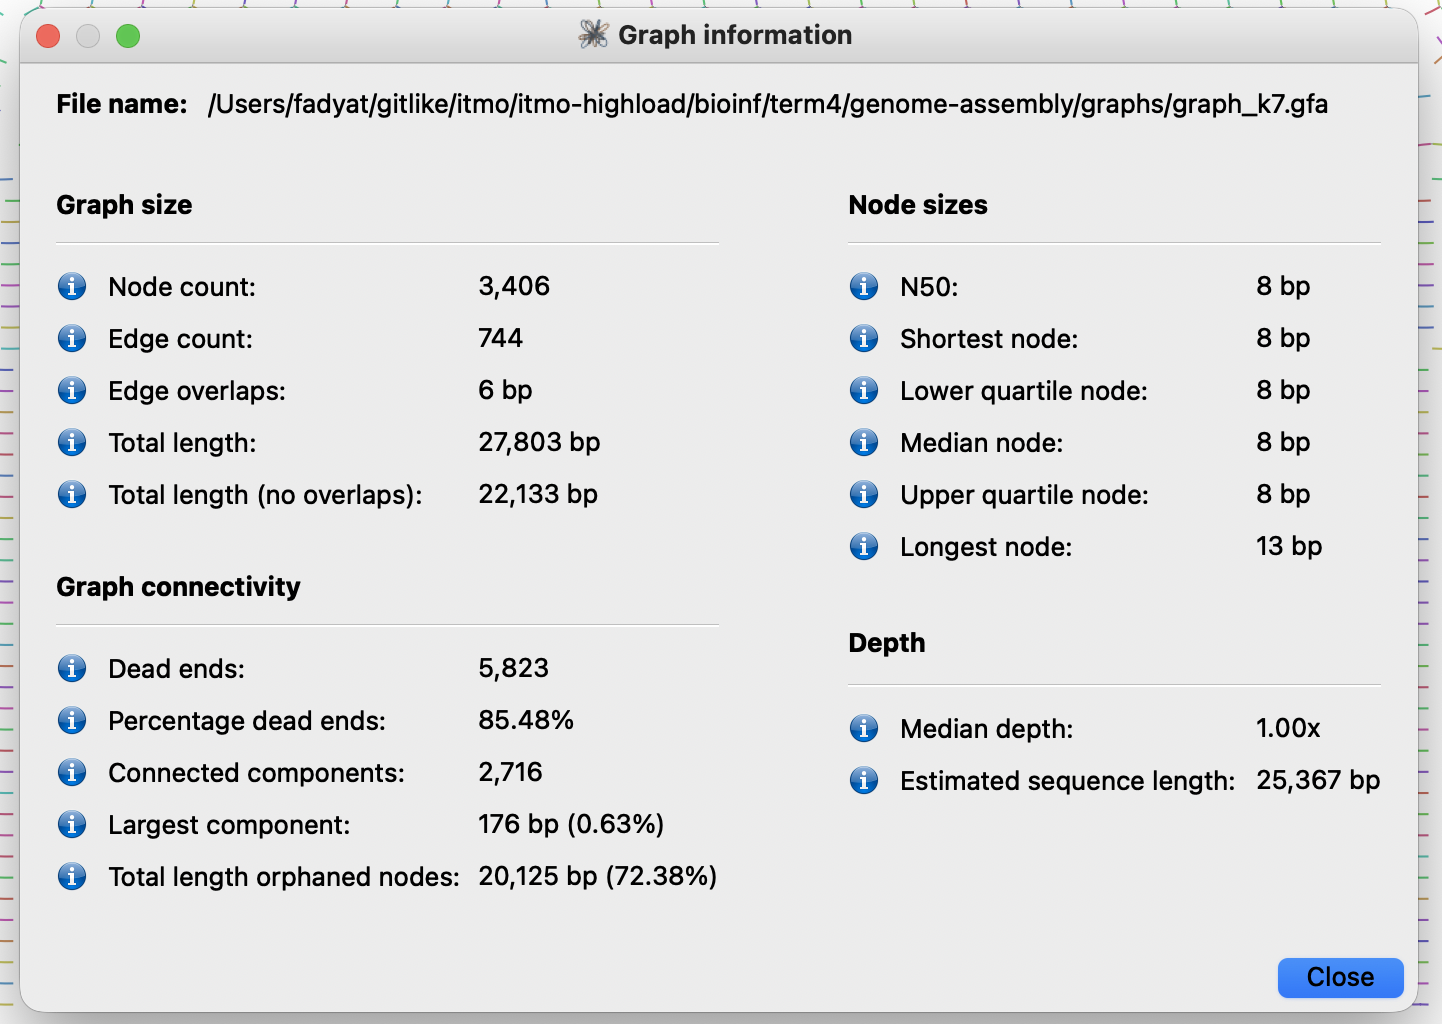

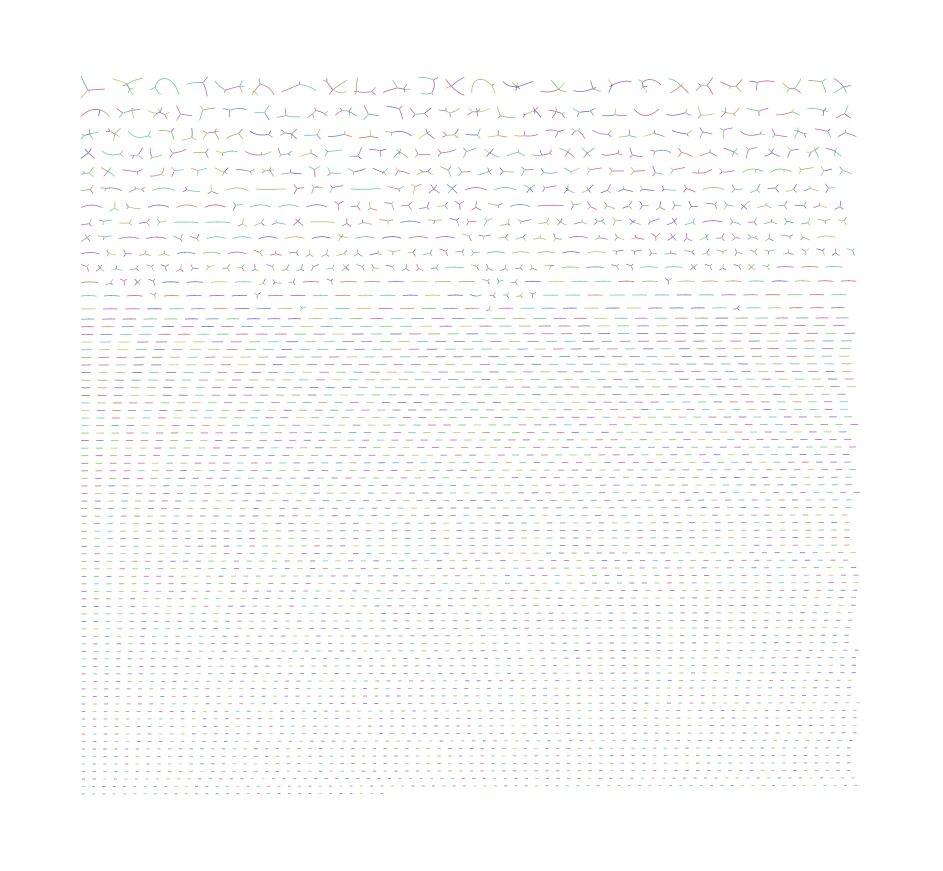

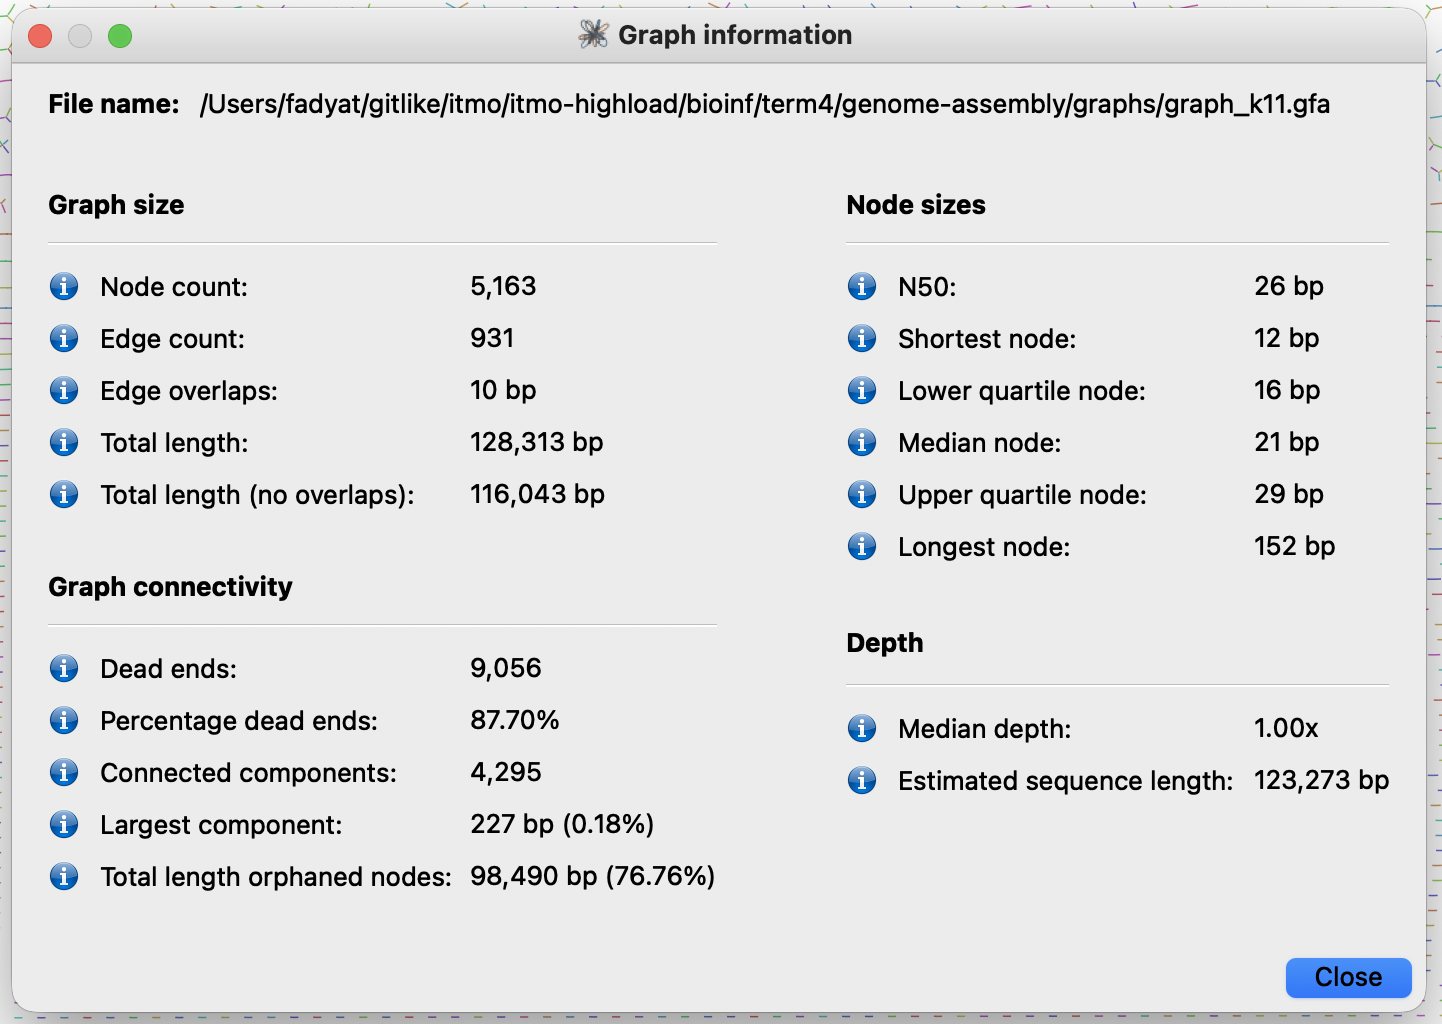

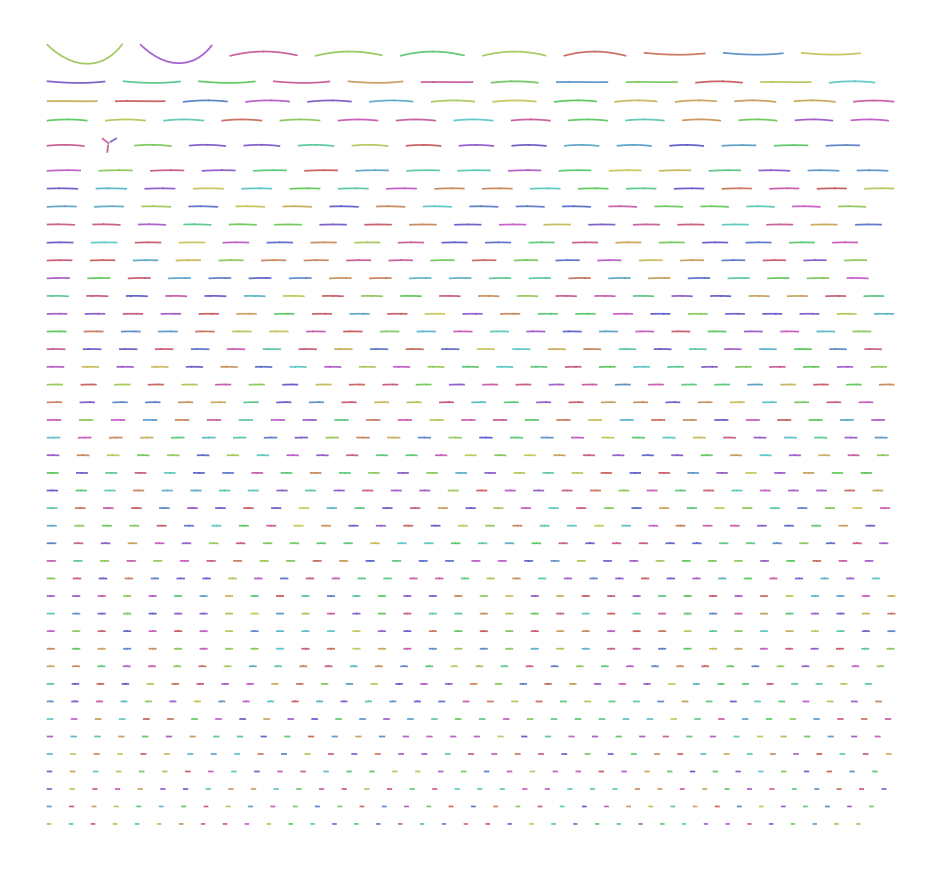

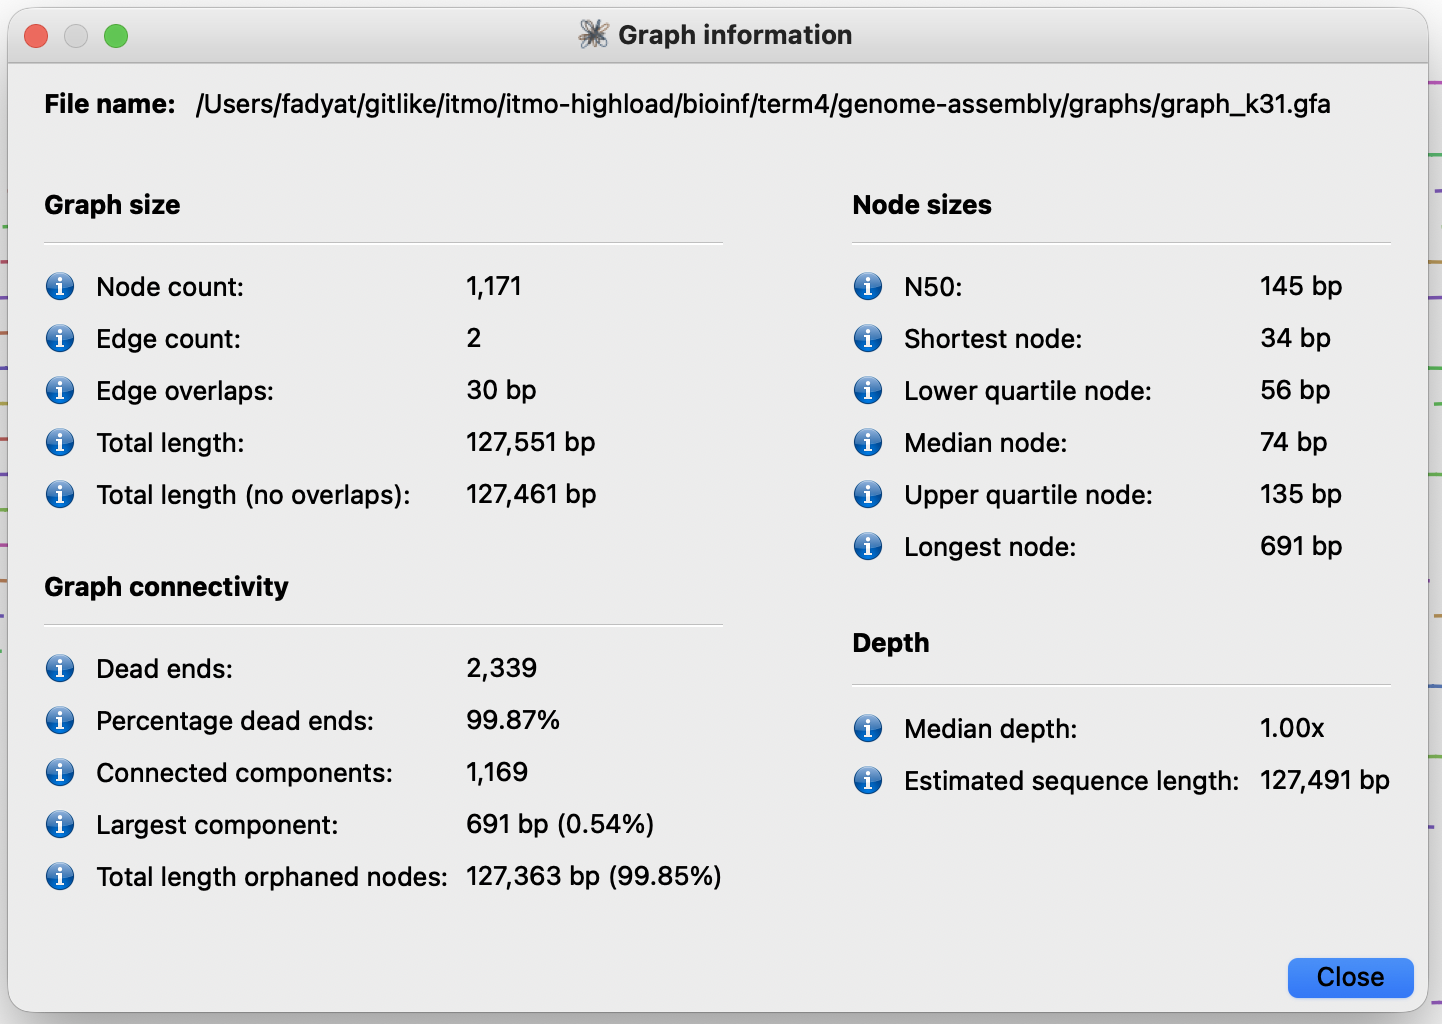

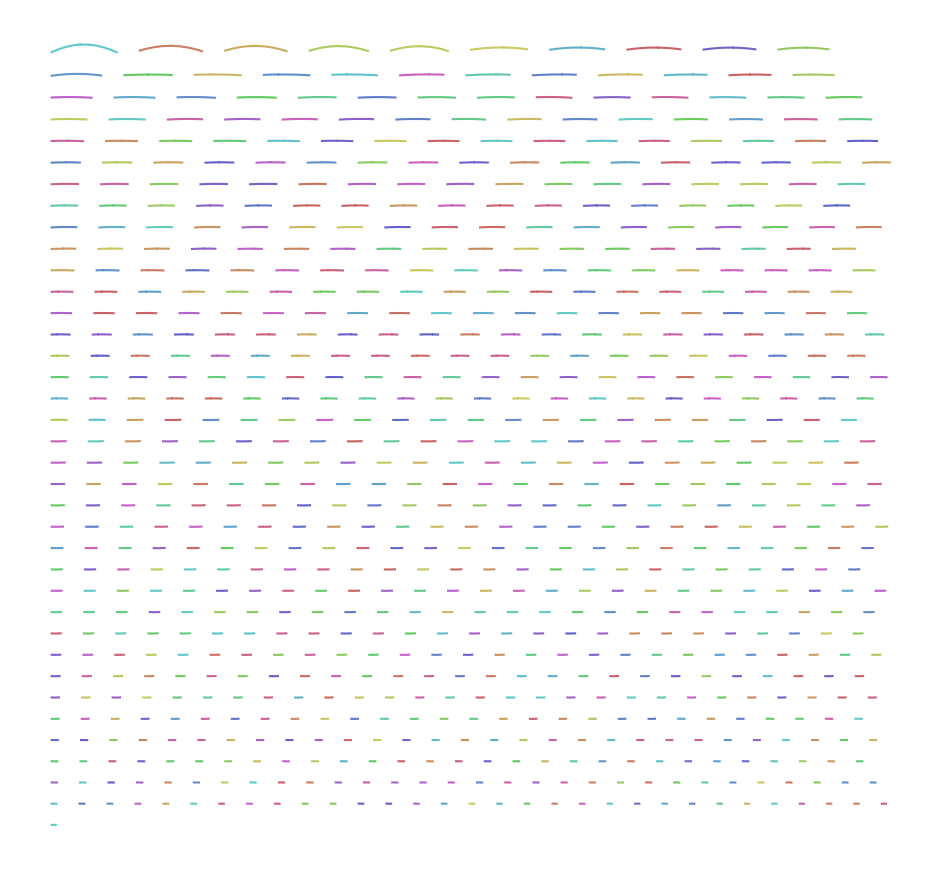

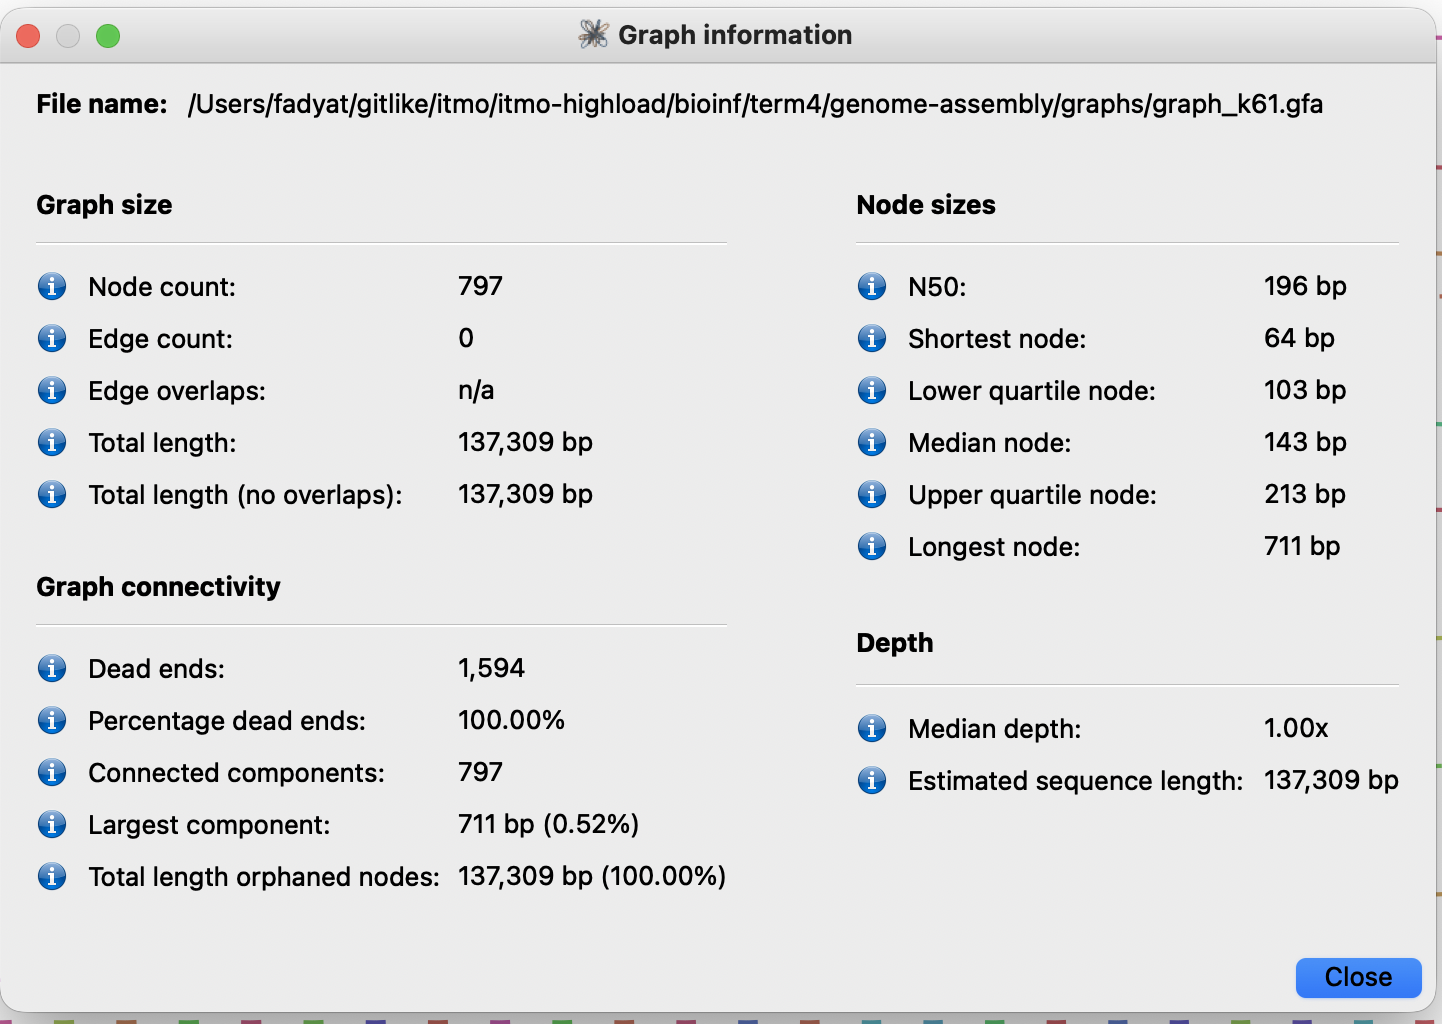

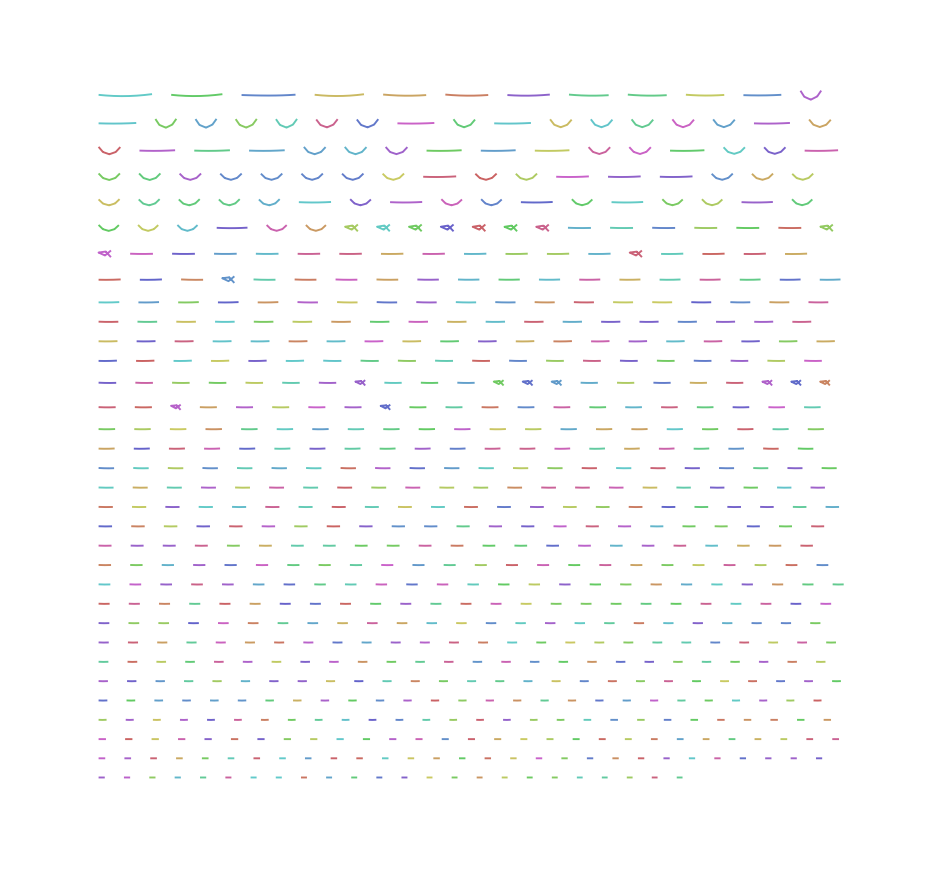

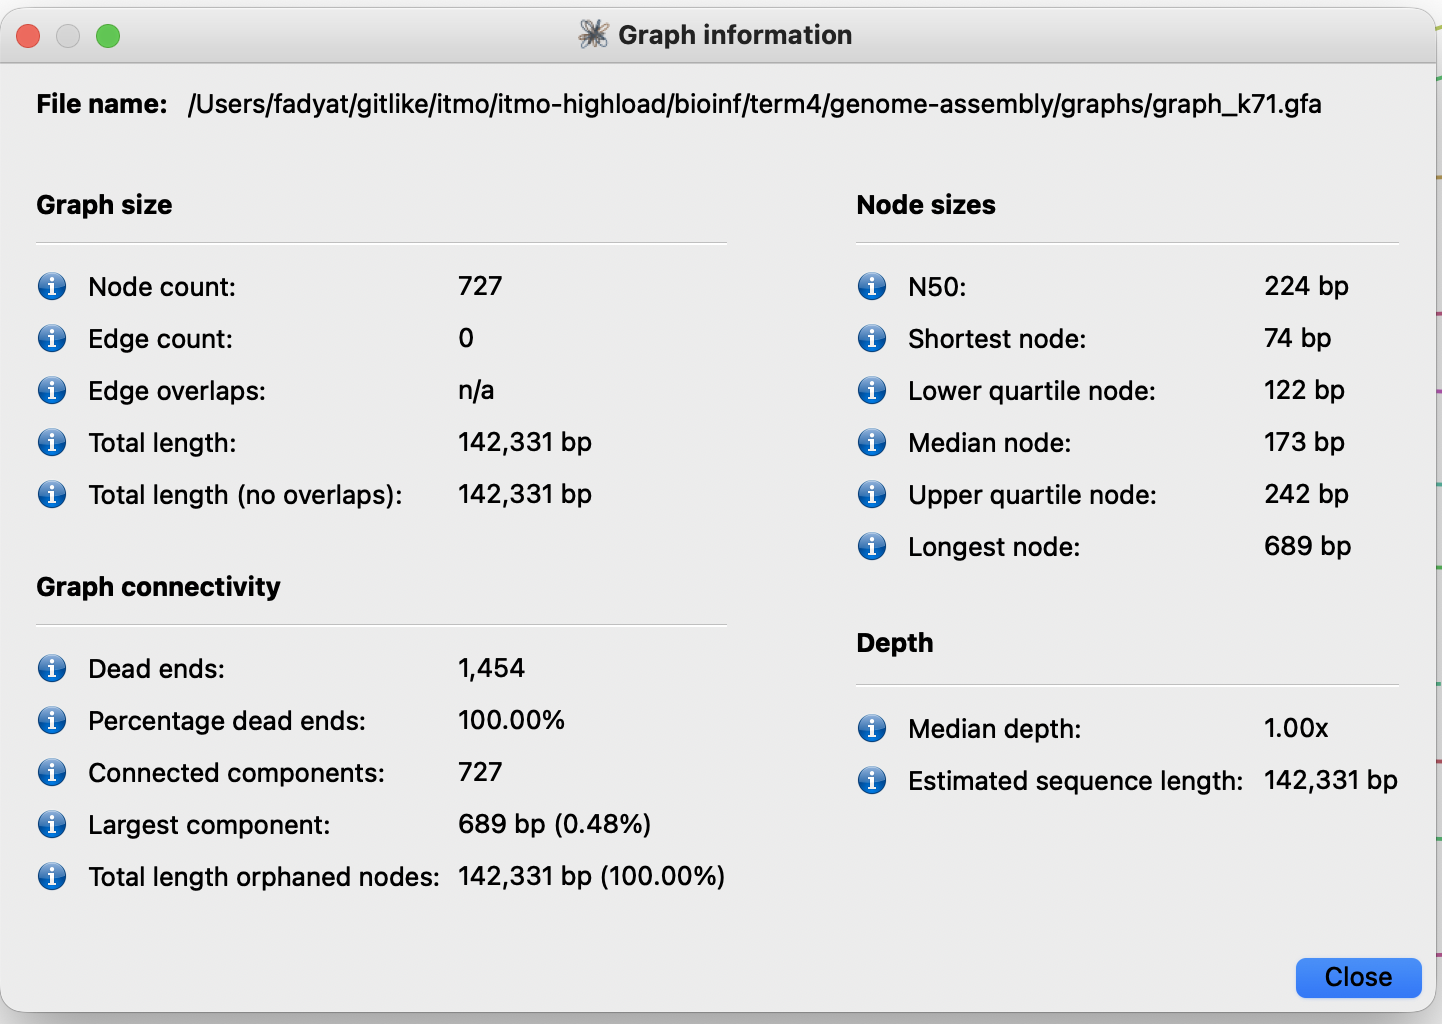

In [18]:
show_images([
    "graphs/graph_k5.png",
    "graphs/graph_k5_info.png",
    "graphs/graph_k7.png",
    "graphs/graph_k7_info.png",
    "graphs/graph_k11.png",
    "graphs/graph_k11_info.png",
    "graphs/graph_k31.png",
    "graphs/graph_k31_info.png",
    "graphs/graph_k61.png",
    "graphs/graph_k61_info.png",
    "graphs/graph_k71.png",
    "graphs/graph_k71_info.png"
])

In [22]:
def save_contigs_fasta(g: CompressedDeBruijnGraph, path: str):
    """
    Save all linear unitigs (compacted edges) as contigs in FASTA format.

    Each contig gets a unique identifier.
    """

    with open(path, 'w') as f:
        contig_id = 0
        for start, edges in g.compacted_edges.items():
            for edge in edges:
                f.write(f">contig_{contig_id} len={len(edge.seq)} kmers={edge.kmers_number} depth={edge.depth_sum}\n")
                f.write(f"{edge.seq}\n")
                contig_id += 1

In [23]:
graph = CompressedDeBruijnGraph(k=31)
graph.build(tuple(r.seq for r in data))

save_contigs_fasta(graph, "contigs_k31.fasta")

In [24]:
!head -n 10 contigs_k31.fasta

>contig_0 len=63 kmers=32 depth=32
CGACGGTACGTTACAGGGCATTCATCGCACCTATAAACCGGCATTCAGCTTCCAGGGGCACCC
>contig_1 len=39 kmers=8 depth=47
CGACGGTACGTTACAGGGCATTCATCGCACCGATAAACC
>contig_2 len=37 kmers=6 depth=64
AAGGATCAGCGCCTGTTTGCGAATCACGCCCACCTGA
>contig_3 len=63 kmers=32 depth=316
CACAGAGATTTATGCCCGGCGCTGCAACGTCCGCGACGAATATCCTGCGGGCGGGTGGTACCG
>contig_4 len=63 kmers=32 depth=32
CACAGAGATTTATGCCCGGCGCTGCAACGTCAGCGACGAATATCCTGCGGGCGGGTGGTACCG


### Вывод по эксперименту:

В данной работе мы реализовали алгоритмы построения и упрощения де-Брейновых графов для сборки генома на основе коротких ридов.

Мы построили сжатые де-Брейновы графы для различных значений k и применили две эвристики: удаление низкоковерных юнитигов и удаление коротких тупиков.

Результаты показали, что при малых k граф содержит много ветвлений и шумов, что затрудняет сборку. При больших k граф становится более разреженным, но может терять информацию о перекрытиях между ридами.

Честно, говоря не понял какое значение в данном случае оптимальное, так как граф почти всегда слишком разреженный - возможно, где-то есть ошибка в самом коде.